In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 20000

<Figure size 640x480 with 0 Axes>

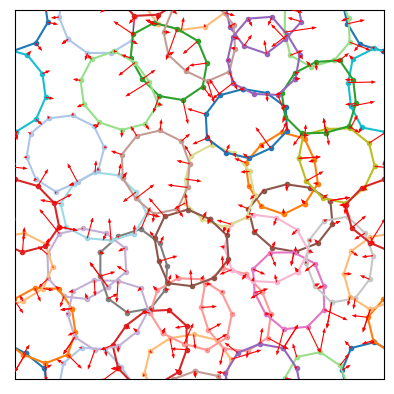

In [3]:
numPolygons = 32
n = 10
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 5
phi = 1.0
kappa = 3.65
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
#m.generateRandomPolygons(numPolygons, n, kappa = kappa, phi = phi)
modelDir = "playersTesting/" + str(np.max(np.array(os.listdir("playersTesting")).astype(int)))
m.loadModel(modelDir)
plt.clf()
# Works fine
m.setMaxEdgeLength()
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.updateConstraintForces()
force0 = m.getConstraintForces()
positions0 = m.getPositions()# Now you have dA, can you draw arrows on the vertices?
artists = m.draw(forces = force0, arrowColor = 'r')

In [ ]:
startPos = m.getPositions()
m.minimizeGD(dt = 1e-3, maxSteps = maxSteps, progressBar = True, checkpointDir = "SDTesting", checkpointFreq = 1000)
positions0 = m.getPositions()

Processing:   2%|▌                        | 424/20000 [00:00<00:13, 1455.81it/s]